In [66]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [67]:
# Load the datasets
df_fake = pd.read_csv("dataset/Fake.csv")
df_real = pd.read_csv("dataset/True.csv")

In [68]:
# Display basic information about the dataset                
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    44898 non-null  object
 1   label   44898 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 701.7+ KB


In [69]:
# Show samples
print("Fake news sample:")
df_fake.head()

print("\nReal news sample:")
df_real.head()

Fake news sample:

Real news sample:


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [70]:
# Add labels

df_fake["label"] = 0  # Fake
df_real["label"] = 1  # Real

In [71]:
# Combine datasets
df = pd.concat([df_fake, df_real], axis=0)

In [72]:
# Shuffle the dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [73]:
# Preview
df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [74]:
# Dataset shape
print("Dataset shape:", df.shape)

Dataset shape: (44898, 5)


In [75]:
# Keep only 'text' and 'label'
df = df[["text", "label"]]
# Strip leading/trailing space
df["text"] = df["text"].str.strip()
# Preview cleaned data
df.head()

,text,label
0,"21st Century Wire says Ben Stein, reputable pr...",0
1,WASHINGTON (Reuters) - U.S. President Donald T...,1
2,(Reuters) - Puerto Rico Governor Ricardo Rosse...,1
3,"On Monday, Donald Trump once again embarrassed...",0
4,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",1


In [76]:
#-------------------------------
# Split the Data (Train/Test)
#-------------------------------

In [77]:
# Features (X) and Labels (y)
X = df['text']
y = df['label']

# 📤 Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [78]:
#--------------------------------
# TF-IDF Vectorization
#--------------------------------

In [79]:
# Initialize TF-IDF vectorizer
tfidf = TfidfVectorizer(stop_words='english', max_df=0.7)

# Learn vocabulary from training data and transform it
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform test data
X_test_tfidf = tfidf.transform(X_test)

In [80]:
#----------------------------------
# Train a Logistic Regression Model
#----------------------------------

In [81]:
# Initialize the model
model = LogisticRegression(max_iter=1000)

# Train the model on TF-IDF features
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [82]:
#----------------------------------
# Make Predictions
#----------------------------------

In [83]:
# Predict on the test set
y_pred = model.predict(X_test_tfidf)

In [84]:
#----------------------------------
# Evaluate the Model
#----------------------------------

Accuracy: 0.982739420935412
Precision: 0.9785996743428704
Recall: 0.9852459016393442
F1-score: 0.9819115416034543

Classification Report:
              precision    recall  f1-score   support

        Fake       0.99      0.98      0.98      4710
        Real       0.98      0.99      0.98      4270

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980



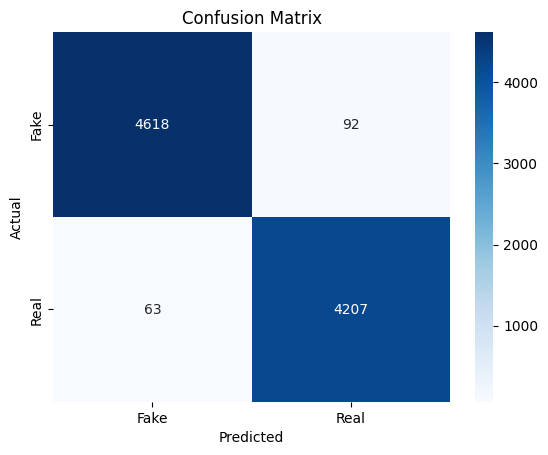

In [85]:
# Print classification metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Fake", "Real"]))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()